In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/mlp-kaggle-assignment-2-may-2026-term/sample_submission.csv
/kaggle/input/competitions/mlp-kaggle-assignment-2-may-2026-term/train.csv
/kaggle/input/competitions/mlp-kaggle-assignment-2-may-2026-term/test.csv


In [2]:
# ==========================================
# Import Required Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
# ==========================================
# Load Dataset
# ==========================================
train = "/kaggle/input/competitions/mlp-kaggle-assignment-2-may-2026-term/train.csv"
test = "/kaggle/input/competitions/mlp-kaggle-assignment-2-may-2026-term/test.csv"

train_df = pd.read_csv(train)
test_df = pd.read_csv(test)

print("Train Shape :", train_df.shape)
print("Test Shape  :", test_df.shape)

train_df.head()

Train Shape : (90000, 14)
Test Shape  : (30000, 13)


,id,customer_id,last_name,credit_score,country,gender,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary,exit_status
0,0,15788291,Iredale,559.0,France,Male,28.0,1,149989.39,1.0,1.0,1.0,67622.46,0
1,1,15642816,Hs?,694.0,France,Female,37.0,7,114510.35,2.0,0.0,0.0,182797.86,0
2,2,15632272,T'ien,585.0,NaN,Female,45.0,8,NaN,2.0,1.0,1.0,170338.35,0
3,3,15685826,Hightower,589.0,Spain,Male,25.0,0,166082.18,1.0,1.0,1.0,166476.46,0
4,4,15658032,Hopkins,701.0,France,Male,39.0,2,0.00,2.0,1.0,0.0,82526.92,0


In [4]:
# ==========================================
# Dataset Information
# ==========================================

print("="*50)
print("Training Dataset Information")
print("="*50)

train_df.info()

Training Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                90000 non-null  int64  
 1   customer_id       90000 non-null  int64  
 2   last_name         90000 non-null  object 
 3   credit_score      80444 non-null  float64
 4   country           83979 non-null  object 
 5   gender            90000 non-null  object 
 6   age               90000 non-null  float64
 7   tenure            90000 non-null  int64  
 8   acc_balance       82743 non-null  float64
 9   prod_count        85137 non-null  float64
 10  has_card          90000 non-null  float64
 11  is_active         90000 non-null  float64
 12  estimated_salary  90000 non-null  float64
 13  exit_status       90000 non-null  int64  
dtypes: float64(7), int64(4), object(3)
memory usage: 9.6+ MB


In [5]:
# ==========================================
# Data Types of Columns
# ==========================================

dtype_summary = pd.DataFrame({
    "Column": train_df.columns,
    "Data Type": train_df.dtypes.astype(str).values
})

display(dtype_summary)

,Column,Data Type
0,id,int64
1,customer_id,int64
2,last_name,object
3,credit_score,float64
4,country,object
5,gender,object
6,age,float64
7,tenure,int64
8,acc_balance,float64
9,prod_count,float64


In [6]:
# ==========================================
# Descriptive Statistics of Numerical Columns
# ==========================================

# Select numerical columns
numerical_cols = train_df.select_dtypes(include=["int64", "float64"]).columns

# Descriptive statistics
desc_stats = train_df[numerical_cols].describe().T

# Add Median
desc_stats["median"] = train_df[numerical_cols].median()

# Rearrange columns for better readability
desc_stats = desc_stats[
    ["count", "mean", "median", "std", "min", "25%", "50%", "75%", "max"]
]

display(desc_stats.round(2))

,count,mean,median,std,min,25%,50%,75%,max
id,90000.0,44999.50,44999.50,25980.91,0.00,22499.75,44999.50,67499.25,89999.00
customer_id,90000.0,15692086.87,15690164.00,71297.96,15565701.00,15633608.00,15690164.00,15756743.00,15815690.00
credit_score,80444.0,656.50,659.00,80.02,350.00,597.00,659.00,710.00,850.00
age,90000.0,38.12,37.00,8.86,18.00,32.00,37.00,42.00,92.00
tenure,90000.0,5.02,5.00,2.80,0.00,3.00,5.00,7.00,10.00
acc_balance,82743.0,55456.73,0.00,62788.47,0.00,0.00,0.00,119825.75,250898.09
prod_count,85137.0,1.55,2.00,0.55,1.00,1.00,2.00,2.00,4.00
has_card,90000.0,0.75,1.00,0.43,0.00,1.00,1.00,1.00,1.00
is_active,90000.0,0.50,0.00,0.50,0.00,0.00,0.00,1.00,1.00
estimated_salary,90000.0,112394.66,117505.07,50360.44,11.58,74430.36,117505.07,154874.79,199992.48


In [7]:
# ==========================================
# Missing Value Analysis
# ==========================================

missing_values = pd.DataFrame({
    "Missing Count": train_df.isnull().sum(),
    "Missing Percentage": (train_df.isnull().sum() / len(train_df)) * 100
})

missing_values = missing_values[missing_values["Missing Count"] > 0]
missing_values = missing_values.sort_values(by="Missing Percentage", ascending=False)

display(missing_values.round(2))

,Missing Count,Missing Percentage
credit_score,9556,10.62
acc_balance,7257,8.06
country,6021,6.69
prod_count,4863,5.40


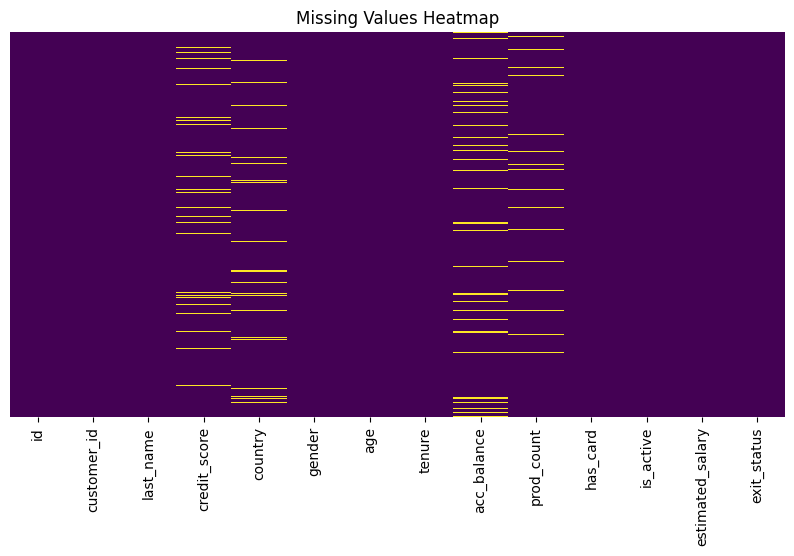

In [8]:
# ==========================================
# Visualize Missing Values
# ==========================================

plt.figure(figsize=(10,5))

sns.heatmap(
    train_df.isnull(),
    cbar=False,
    cmap="viridis",
    yticklabels=False
)

plt.title("Missing Values Heatmap")
plt.show()

In [9]:
# ==========================================
# Handle Missing Values
# ==========================================

# Separate numerical and categorical columns
numerical_cols = train_df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = train_df.select_dtypes(include=["object"]).columns

# Remove target column if present
numerical_cols = numerical_cols.drop("exit_status", errors="ignore")

# Median Imputation for Numerical Features
for col in numerical_cols:
    train_df[col].fillna(train_df[col].median(), inplace=True)
    test_df[col].fillna(train_df[col].median(), inplace=True)

# Mode Imputation for Categorical Features
for col in categorical_cols:
    train_df[col].fillna(train_df[col].mode()[0], inplace=True)
    test_df[col].fillna(train_df[col].mode()[0], inplace=True)

In [10]:
# ==========================================
# Verify Missing Values
# ==========================================

print("Missing Values in Training Data")
display(train_df.isnull().sum())

print("\nMissing Values in Test Data")
display(test_df.isnull().sum())

Missing Values in Training Data


id                  0
customer_id         0
last_name           0
credit_score        0
country             0
gender              0
age                 0
tenure              0
acc_balance         0
prod_count          0
has_card            0
is_active           0
estimated_salary    0
exit_status         0
dtype: int64


Missing Values in Test Data


id                  0
customer_id         0
last_name           0
credit_score        0
country             0
gender              0
age                 0
tenure              0
acc_balance         0
prod_count          0
has_card            0
is_active           0
estimated_salary    0
dtype: int64

In [11]:
# ==========================================
# Duplicate Records
# ==========================================

duplicate_count = train_df.duplicated().sum()

print(f"Number of Duplicate Rows: {duplicate_count}")

Number of Duplicate Rows: 0


In [12]:
# ==========================================
# Verify Duplicate Removal
# ==========================================

print("Duplicate Rows Remaining:", train_df.duplicated().sum())

Duplicate Rows Remaining: 0


In [13]:
# ==========================================
# Detect Outliers using IQR Method
# ==========================================

# Select numerical columns (excluding identifiers and target)
numerical_cols = train_df.select_dtypes(include=["int64", "float64"]).columns.tolist()

for col in ["id", "record_id", "customer_id", "exit_status"]:
    if col in numerical_cols:
        numerical_cols.remove(col)

outlier_summary = []

for col in numerical_cols:
    
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((train_df[col] < lower) | (train_df[col] > upper)).sum()

    outlier_summary.append({
        "Feature": col,
        "Outliers": outliers,
        "Percentage": round((outliers / len(train_df)) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(outlier_summary)

,Feature,Outliers,Percentage
0,credit_score,605,0.67
1,age,3411,3.79
2,tenure,0,0.00
3,acc_balance,0,0.00
4,prod_count,263,0.29
5,has_card,22114,24.57
6,is_active,0,0.00
7,estimated_salary,0,0.00


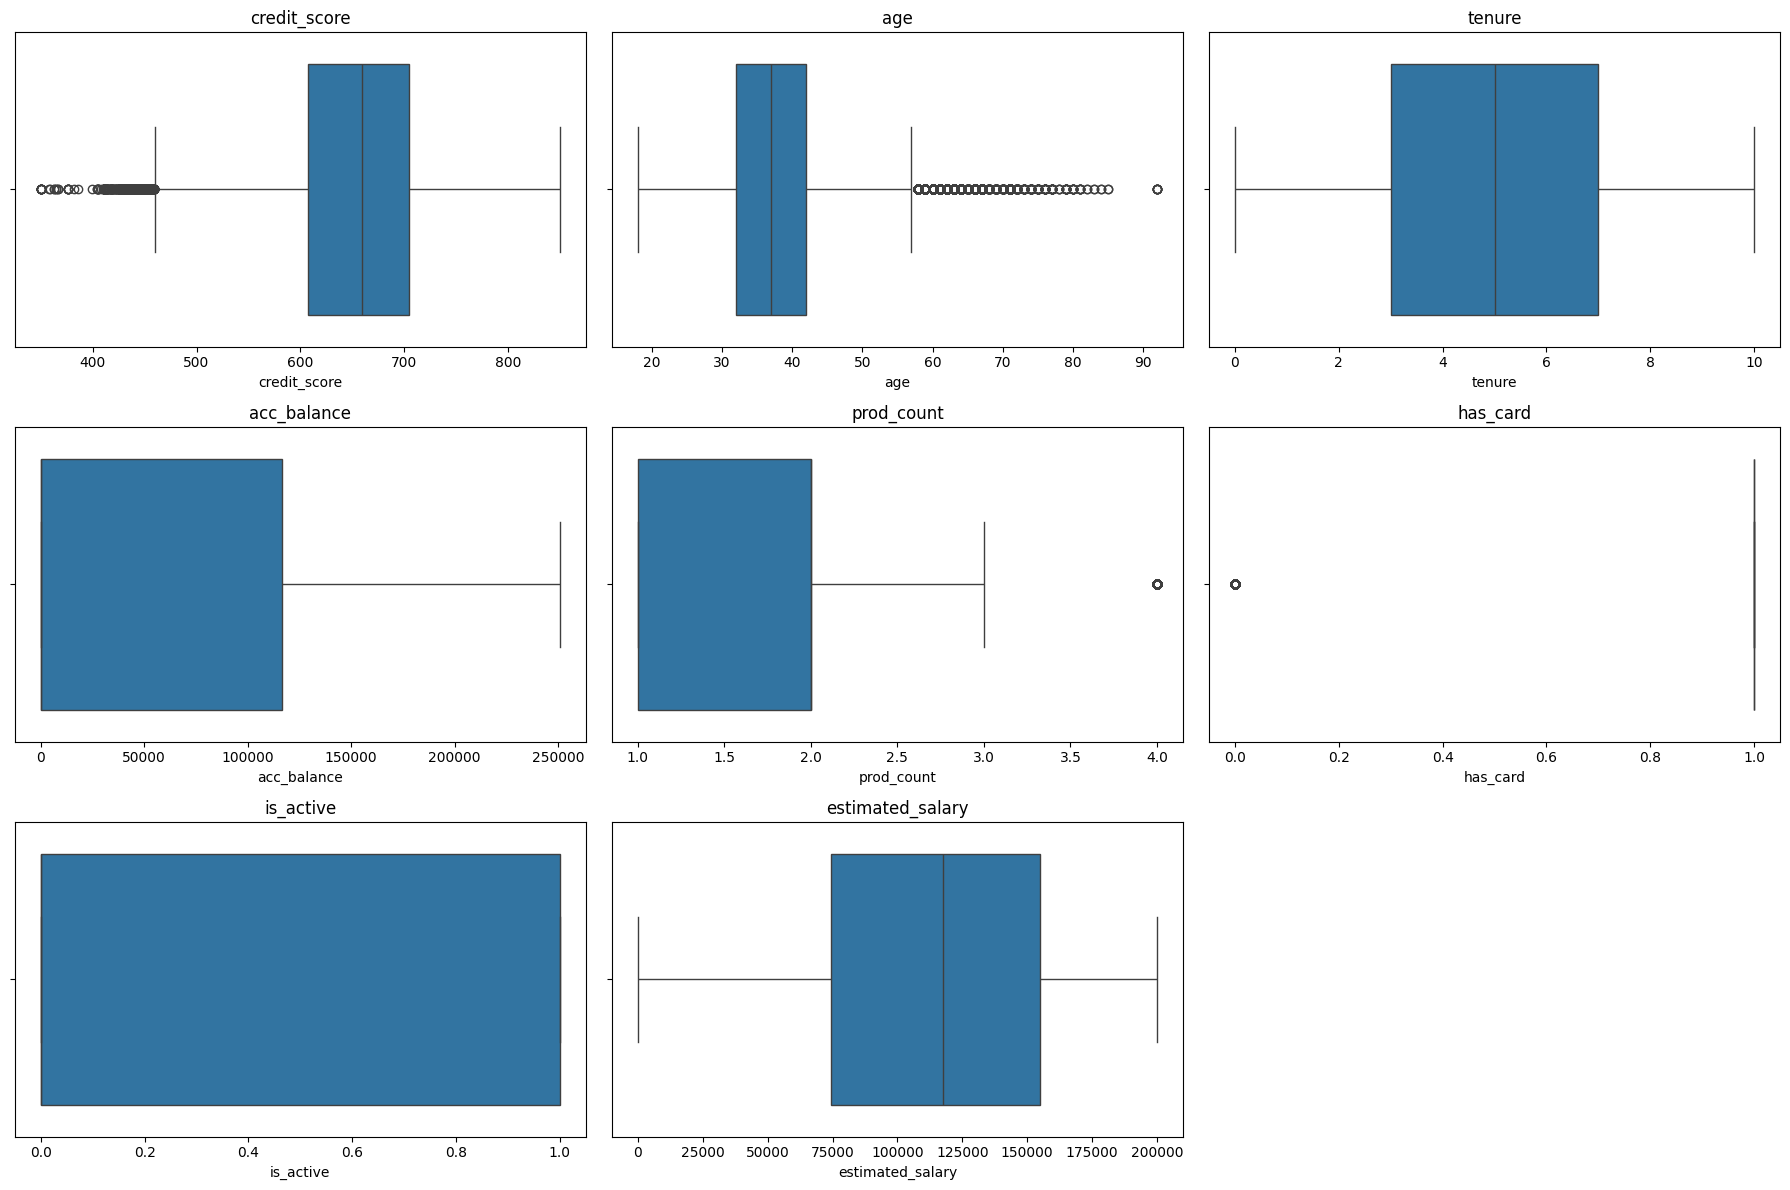

In [14]:
# ==========================================
# Boxplots for Numerical Features
# ==========================================

plt.figure(figsize=(18,12))

for i, col in enumerate(numerical_cols, 1):
    
    plt.subplot((len(numerical_cols)+2)//3, 3, i)
    
    sns.boxplot(x=train_df[col])
    
    plt.title(col)

plt.tight_layout()
plt.show()

In [15]:
# ==========================================
# Handle Outliers using IQR Capping
# ==========================================

for col in numerical_cols:

    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    train_df[col] = train_df[col].clip(lower, upper)
    test_df[col] = test_df[col].clip(lower, upper)

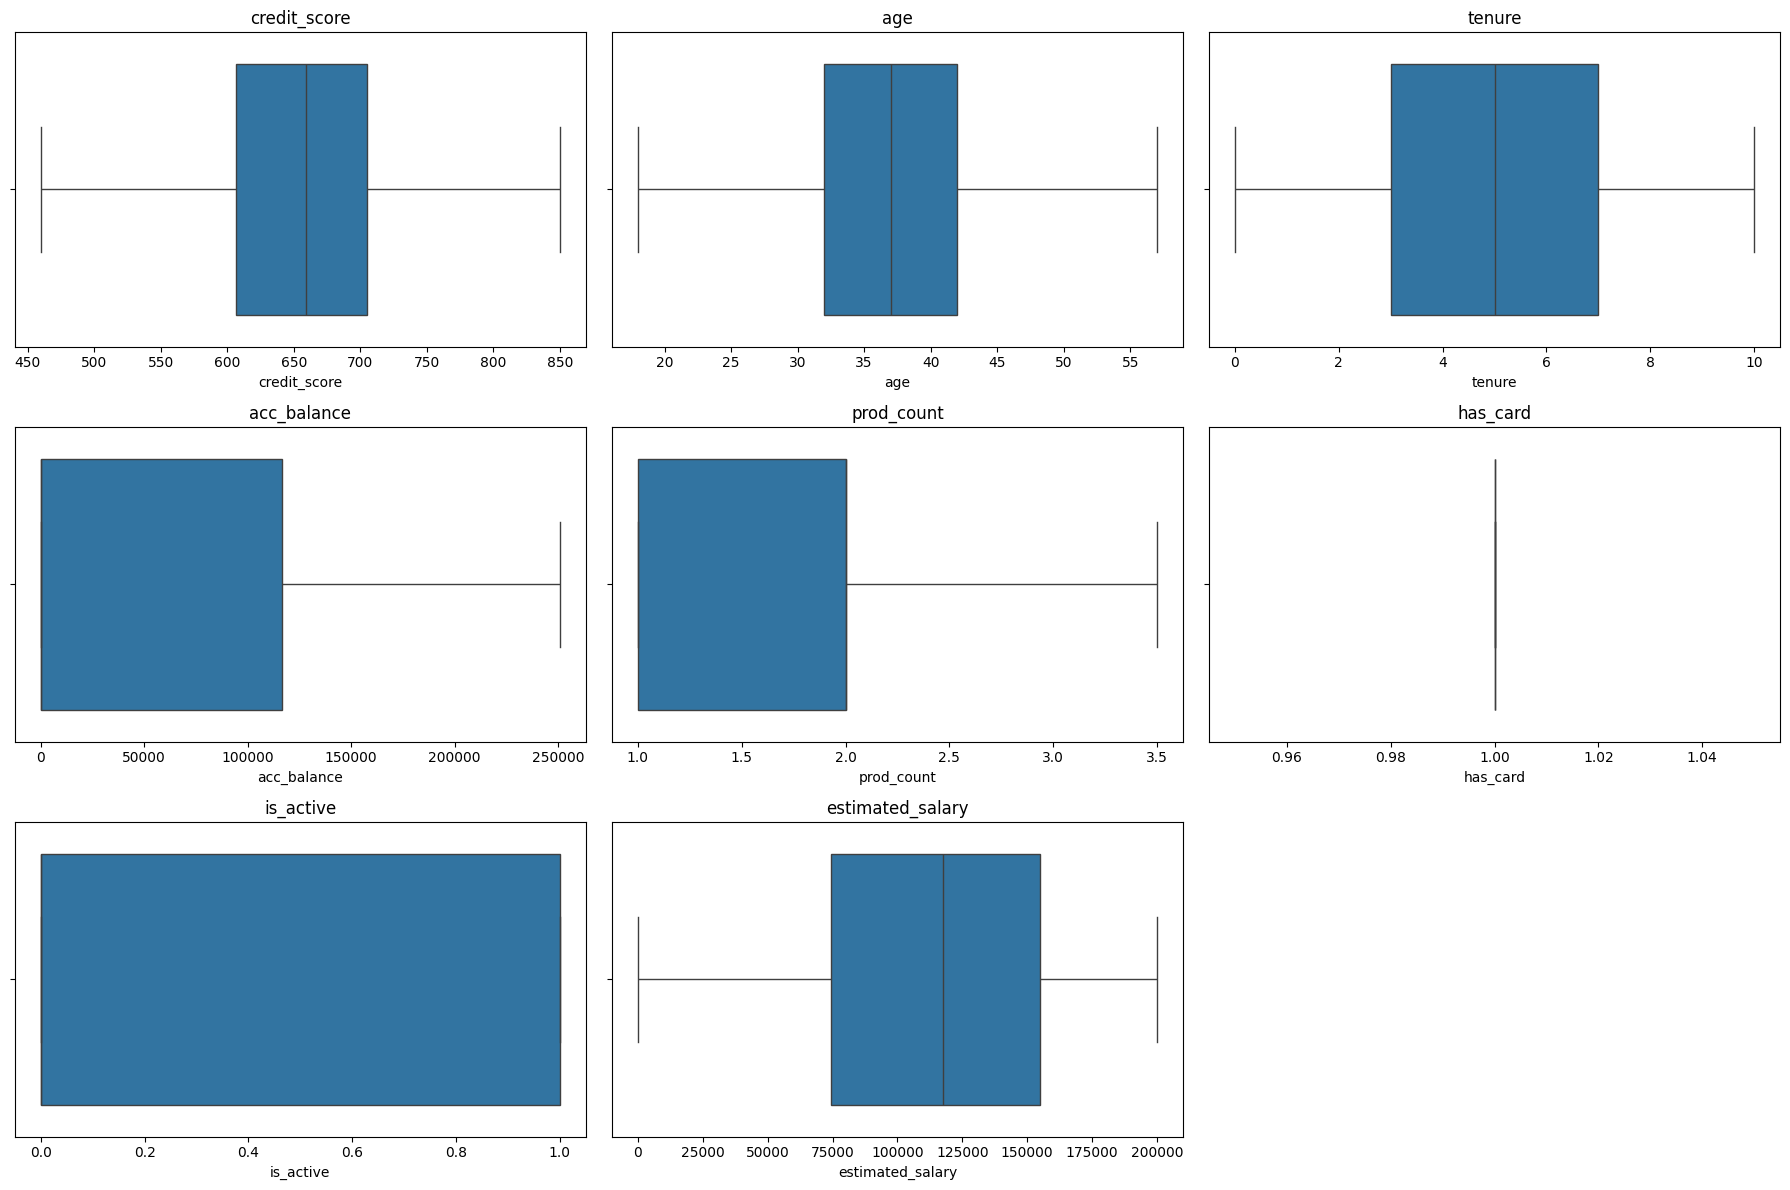

In [16]:
# ==========================================
# Verify Outlier Treatment
# ==========================================

plt.figure(figsize=(18,12))

for i, col in enumerate(numerical_cols, 1):
    
    plt.subplot((len(numerical_cols)+2)//3, 3, i)
    
    sns.boxplot(x=train_df[col])
    
    plt.title(col)

plt.tight_layout()
plt.show()

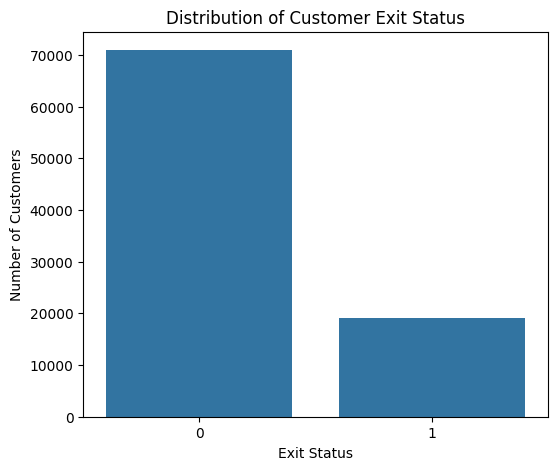

In [17]:
# ==========================================
# Distribution of Target Variable
# ==========================================

plt.figure(figsize=(6,5))

sns.countplot(x="exit_status", data=train_df)

plt.title("Distribution of Customer Exit Status")
plt.xlabel("Exit Status")
plt.ylabel("Number of Customers")

plt.show()

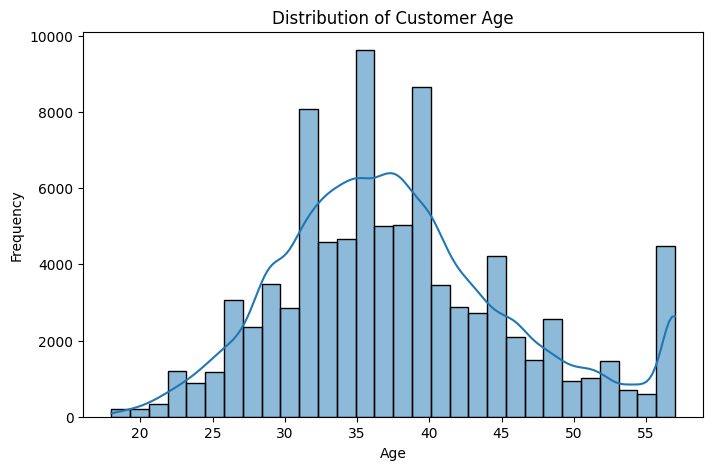

In [18]:
# ==========================================
# Age Distribution
# ==========================================

plt.figure(figsize=(8,5))

sns.histplot(train_df["age"], bins=30, kde=True)

plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

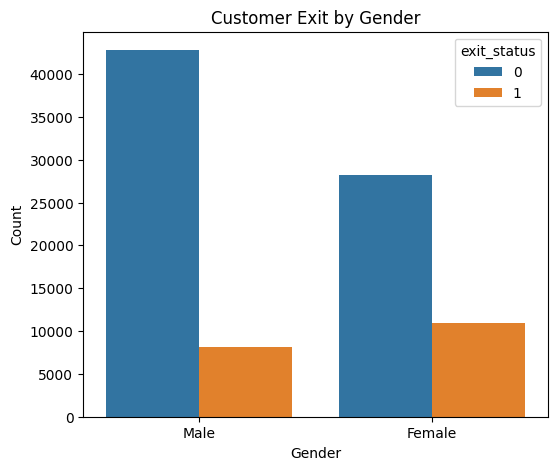

In [19]:
# ==========================================
# Exit Status by Gender
# ==========================================

plt.figure(figsize=(6,5))

sns.countplot(
    x="gender",
    hue="exit_status",
    data=train_df
)

plt.title("Customer Exit by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

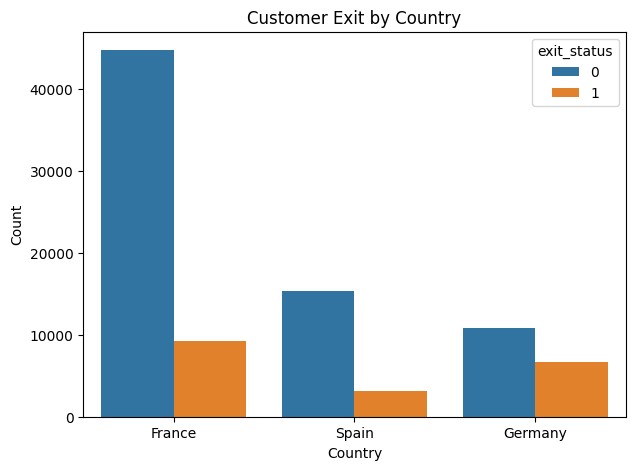

In [20]:
# ==========================================
# Exit Status by Country
# ==========================================

plt.figure(figsize=(7,5))

sns.countplot(
    x="country",
    hue="exit_status",
    data=train_df
)

plt.title("Customer Exit by Country")
plt.xlabel("Country")
plt.ylabel("Count")

plt.show()

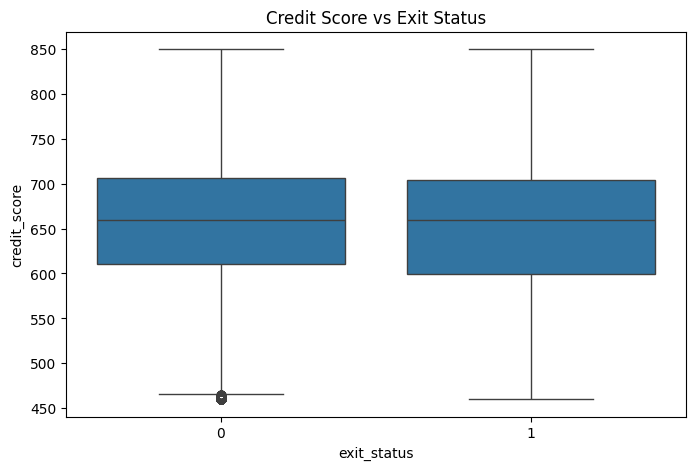

In [21]:
# ==========================================
# Credit Score vs Exit Status
# ==========================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x="exit_status",
    y="credit_score",
    data=train_df
)

plt.title("Credit Score vs Exit Status")

plt.show()

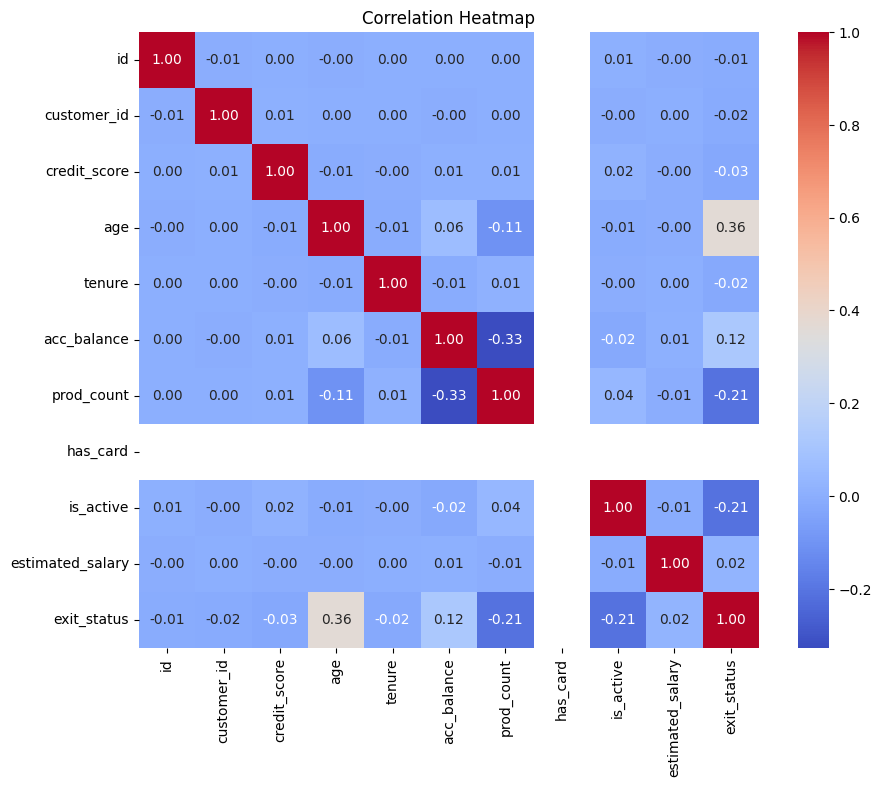

In [22]:
# ==========================================
# Correlation Heatmap
# ==========================================

plt.figure(figsize=(10,8))

numeric_df = train_df.select_dtypes(include=["int64", "float64"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [23]:
# ==========================================
# Separate Features and Target
# ==========================================

X = train_df.drop(columns=["exit_status"])
y = train_df["exit_status"]

# Drop identifier columns
drop_cols = ["id", "record_id", "customer_id"]

drop_cols = [col for col in drop_cols if col in X.columns]

X = X.drop(columns=drop_cols)

test_data = test_df.drop(columns=drop_cols, errors="ignore")

In [24]:
# ==========================================
# Train Validation Split
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Validation Shape :", X_valid.shape)

Training Shape : (72000, 11)
Validation Shape : (18000, 11)


In [25]:
# ============================================================
# FEATURE ENGINEERING + ENCODING (OPTIMIZED)
# ============================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold

# ============================================================
# FEATURE ENGINEERING
# ============================================================

for df in [X_train, X_valid, test_data]:

    # Original Features
    df["BalanceSalaryRatio"] = df["acc_balance"] / (df["estimated_salary"] + 1)

    df["CreditAge"] = df["credit_score"] * df["age"]

    df["ProductsPerTenure"] = df["prod_count"] / (df["tenure"] + 1)

    df["InactiveBalance"] = df["acc_balance"] * (1 - df["is_active"])

    df["AgeBucket"] = pd.cut(
        df["age"],
        bins=[18, 30, 40, 50, 60, 100],
        labels=False
    )

    # Strong Interaction Features

    df["BalanceZero"] = (df["acc_balance"] == 0).astype(int)

    df["HighBalance"] = (df["acc_balance"] > 100000).astype(int)

    df["Senior"] = (df["age"] >= 60).astype(int)

    df["Young"] = (df["age"] <= 30).astype(int)

    df["AgeSalary"] = df["age"] * df["estimated_salary"]

    df["CreditSalary"] = (
        df["credit_score"] * df["estimated_salary"]
    )

    df["BalanceAge"] = (
        df["acc_balance"] * df["age"]
    )

    df["TenureAge"] = (
        df["tenure"] * df["age"]
    )

    df["ProductsActive"] = (
        df["prod_count"] * df["is_active"]
    )

    df["ProductsBalance"] = (
        df["prod_count"] * df["acc_balance"]
    )

    df["CreditPerAge"] = (
        df["credit_score"] / (df["age"] + 1)
    )

    df["SalaryPerProduct"] = (
        df["estimated_salary"] / (df["prod_count"] + 1)
    )

    df["BalancePerProduct"] = (
        df["acc_balance"] / (df["prod_count"] + 1)
    )

    df["BalanceCreditRatio"] = (
        df["acc_balance"] / (df["credit_score"] + 1)
    )

    df["TenureProducts"] = (
        df["tenure"] * df["prod_count"]
    )

    df["InactiveHighBalance"] = (
        (
            (df["is_active"] == 0)
            &
            (df["acc_balance"] > 100000)
        ).astype(int)
    )

# ============================================================
# GENDER ENCODING
# ============================================================

gender_map = {
    "Female": 0,
    "Male": 1
}

for df in [X_train, X_valid, test_data]:
    df["gender"] = df["gender"].map(gender_map)

# ============================================================
# TARGET ENCODING
# ============================================================

global_mean = y_train.mean()

smoothing = 20

categorical_columns = [
    "last_name",
    "country"
]

for col in categorical_columns:

    X_train[col + "_te"] = np.nan

    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    for tr_idx, val_idx in skf.split(X_train, y_train):

        temp = pd.concat(
            [
                X_train.iloc[tr_idx][col],
                y_train.iloc[tr_idx]
            ],
            axis=1
        )

        stats = temp.groupby(col)["exit_status"].agg(
            ["mean", "count"]
        )

        smooth = (
            stats["count"] * stats["mean"]
            +
            smoothing * global_mean
        ) / (
            stats["count"] + smoothing
        )

        X_train.loc[
            X_train.index[val_idx],
            col + "_te"
        ] = (
            X_train.iloc[val_idx][col]
            .map(smooth)
        )

    X_train[col + "_te"] = (
        X_train[col + "_te"]
        .fillna(global_mean)
    )

    temp = pd.concat(
        [
            X_train[col],
            y_train
        ],
        axis=1
    )

    stats = temp.groupby(col)["exit_status"].agg(
        ["mean", "count"]
    )

    smooth = (
        stats["count"] * stats["mean"]
        +
        smoothing * global_mean
    ) / (
        stats["count"] + smoothing
    )

    X_valid[col + "_te"] = (
        X_valid[col]
        .map(smooth)
        .fillna(global_mean)
    )

    test_data[col + "_te"] = (
        test_data[col]
        .map(smooth)
        .fillna(global_mean)
    )

# ============================================================
# DROP HIGH CARDINALITY COLUMNS
# ============================================================

drop_cols = [
    "last_name",
    "country"
]

X_train.drop(columns=drop_cols, inplace=True)

X_valid.drop(columns=drop_cols, inplace=True)

test_data.drop(columns=drop_cols, inplace=True)

# ============================================================
# ALIGN COLUMNS
# ============================================================

X_train, X_valid = X_train.align(
    X_valid,
    join="left",
    axis=1,
    fill_value=0
)

X_train, test_data = X_train.align(
    test_data,
    join="left",
    axis=1,
    fill_value=0
)

print("Train Shape :", X_train.shape)
print("Valid Shape :", X_valid.shape)
print("Test Shape  :", test_data.shape)

Train Shape : (72000, 32)
Valid Shape : (18000, 32)
Test Shape  : (30000, 32)


In [26]:
# ==========================================
# Scale Numerical Features
# ==========================================

from sklearn.preprocessing import StandardScaler

X_train_scaled = X_train.copy()
X_valid_scaled = X_valid.copy()
test_scaled = test_data.copy()

scaler = StandardScaler()

numerical_cols = [
    "credit_score",
    "age",
    "tenure",
    "acc_balance",
    "prod_count",
    "estimated_salary"
]

X_train_scaled[numerical_cols] = scaler.fit_transform(
    X_train[numerical_cols]
)

X_valid_scaled[numerical_cols] = scaler.transform(
    X_valid[numerical_cols]
)

test_scaled[numerical_cols] = scaler.transform(
    test_data[numerical_cols]
)

In [27]:
# ==========================================
# Final Dataset
# ==========================================

print("Training Data Shape :", X_train.shape)
print("Validation Data Shape :", X_valid.shape)
print("Test Data Shape :", test_data.shape)

X_train.head()

Training Data Shape : (72000, 32)
Validation Data Shape : (18000, 32)
Test Data Shape : (30000, 32)


,credit_score,gender,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary,BalanceSalaryRatio,CreditAge,ProductsPerTenure,InactiveBalance,AgeBucket,BalanceZero,HighBalance,Senior,Young,AgeSalary,CreditSalary,BalanceAge,TenureAge,ProductsActive,ProductsBalance,CreditPerAge,SalaryPerProduct,BalancePerProduct,BalanceCreditRatio,TenureProducts,InactiveHighBalance,last_name_te,country_te
68244,710.0,1,27.0,5,0.00,2.0,1.0,0.0,145558.42,0.000000,19170.0,0.333333,0.0,0.0,1,0,0,1,3930077.34,1.033465e+08,0.00,135.0,0.0,0.0,25.357143,48519.473333,0.000000,0.000000,10.0,0,0.162749,0.169475
88137,754.0,1,37.0,8,108887.35,2.0,1.0,1.0,93736.77,1.161617,27898.0,0.222222,0.0,1.0,0,1,0,0,3468260.49,7.067752e+07,4028831.95,296.0,2.0,217774.7,19.842105,31245.590000,36295.783333,144.221656,16.0,0,0.158580,0.380616
16724,552.0,0,33.0,2,0.00,2.0,1.0,0.0,81481.09,0.000000,18216.0,0.666667,0.0,1.0,1,0,0,0,2688875.97,4.497756e+07,0.00,66.0,0.0,0.0,16.235294,27160.363333,0.000000,0.000000,4.0,0,0.282491,0.170030
66767,652.0,0,34.0,2,129255.20,2.0,1.0,1.0,113428.77,1.139517,22168.0,0.666667,0.0,1.0,0,1,0,0,3856578.18,7.395556e+07,4394676.80,68.0,2.0,258510.4,18.628571,37809.590000,43085.066667,197.940582,4.0,0,0.229986,0.384045
61612,659.0,1,44.0,2,0.00,2.0,1.0,1.0,86414.41,0.000000,28996.0,0.666667,0.0,2.0,1,0,0,0,3802234.04,5.694710e+07,0.00,88.0,2.0,0.0,14.644444,28804.803333,0.000000,0.000000,4.0,0,0.214895,0.169475


In [28]:
# ==========================================
# Import Machine Learning Models
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [29]:
# ==========================================
# Train Selected Classification Models
# ==========================================

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

N_SPLITS = 5

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=42
)

oof_cat = np.zeros(len(X_train))
oof_xgb = np.zeros(len(X_train))

test_cat = np.zeros(len(test_data))
test_xgb = np.zeros(len(test_data))

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train)):

    print("="*60)
    print("Fold", fold+1)
    print("="*60)

    X_tr = X_train.iloc[tr_idx]
    y_tr = y_train.iloc[tr_idx]

    X_val = X_train.iloc[val_idx]
    y_val = y_train.iloc[val_idx]

    cat = CatBoostClassifier(

        iterations=4000,

        learning_rate=0.02,

        depth=7,

        loss_function="Logloss",

        eval_metric="AUC",

        random_seed=42,

        l2_leaf_reg=8,

        bagging_temperature=1,

        random_strength=2,

        border_count=128,

        verbose=False

    )

    cat.fit(

        X_tr,
        y_tr,

        eval_set=(X_val,y_val),

        use_best_model=True

    )

    oof_cat[val_idx] = cat.predict_proba(X_val)[:,1]

    test_cat += cat.predict_proba(test_data)[:,1]/N_SPLITS


    xgb = XGBClassifier(

        n_estimators=2500,

        learning_rate=0.015,

        max_depth=5,

        min_child_weight=4,

        subsample=0.85,

        colsample_bytree=0.85,

        gamma=0.15,

        reg_alpha=0.3,

        reg_lambda=3,

        objective="binary:logistic",

        eval_metric="auc",

        tree_method="hist",

        random_state=42,

        n_jobs=-1

    )

    xgb.fit(X_tr,y_tr)

    oof_xgb[val_idx] = xgb.predict_proba(X_val)[:,1]

    test_xgb += xgb.predict_proba(test_data)[:,1]/N_SPLITS

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5


In [30]:
# ============================================================
# MODEL EVALUATION USING OOF PREDICTIONS
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = []

# ------------------------------------------------------------
# CATBOOST
# ------------------------------------------------------------

cat_pred = (oof_cat >= 0.5).astype(int)

results.append({
    "Model": "CatBoost",
    "Accuracy": accuracy_score(y_train, cat_pred),
    "Precision": precision_score(y_train, cat_pred),
    "Recall": recall_score(y_train, cat_pred),
    "F1 Score": f1_score(y_train, cat_pred),
    "ROC AUC": roc_auc_score(y_train, oof_cat)
})

# ------------------------------------------------------------
# XGBOOST
# ------------------------------------------------------------

xgb_pred = (oof_xgb >= 0.5).astype(int)

results.append({
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_train, xgb_pred),
    "Precision": precision_score(y_train, xgb_pred),
    "Recall": recall_score(y_train, xgb_pred),
    "F1 Score": f1_score(y_train, xgb_pred),
    "ROC AUC": roc_auc_score(y_train, oof_xgb)
})

# ------------------------------------------------------------
# WEIGHTED ENSEMBLE
# ------------------------------------------------------------

blend_oof = (
    0.45 * oof_cat +
    0.55 * oof_xgb
)

blend_pred = (blend_oof >= 0.5).astype(int)

results.append({
    "Model": "Weighted Ensemble",
    "Accuracy": accuracy_score(y_train, blend_pred),
    "Precision": precision_score(y_train, blend_pred),
    "Recall": recall_score(y_train, blend_pred),
    "F1 Score": f1_score(y_train, blend_pred),
    "ROC AUC": roc_auc_score(y_train, blend_oof)
})

# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

results_df = (
    pd.DataFrame(results)
    .sort_values("ROC AUC", ascending=False)
    .reset_index(drop=True)
)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,CatBoost,0.863042,0.752633,0.525435,0.618840,0.882518
1,Weighted Ensemble,0.862347,0.748506,0.526288,0.618029,0.881634
2,XGBoost,0.859875,0.736315,0.526223,0.613789,0.877376


In [31]:
# ==========================================
# Hyperparameter Tuning
# ==========================================

from sklearn.model_selection import RandomizedSearchCV

In [32]:
# ==========================================
# Hyperparameter Tuning - XGBoost
# ==========================================

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42
)

xgb_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_params,
    n_iter=10,
    cv=5,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_

print("Best Parameters:")
print(xgb_search.best_params_)

Best Parameters:
{'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}


In [33]:
# ============================================================
# FINAL SUBMISSION (5-FOLD CV VERSION)
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import f1_score

# ============================================================
# OOF ENSEMBLE
# ============================================================

blend_oof = (
    0.55 * oof_cat +
    0.45 * oof_xgb
)

# ============================================================
# FIND BEST THRESHOLD
# ============================================================

best_threshold = 0.50
best_f1 = 0

for threshold in np.arange(0.20, 0.80, 0.005):

    pred = (blend_oof >= threshold).astype(int)

    score = f1_score(y_train, pred)

    if score > best_f1:
        best_f1 = score
        best_threshold = threshold

print("=" * 60)
print(f"Best Threshold : {best_threshold:.3f}")
print(f"OOF F1 Score   : {best_f1:.5f}")
print("=" * 60)

# ============================================================
# TEST ENSEMBLE
# ============================================================

blend_test = (
    0.55 * test_cat +
    0.45 * test_xgb
)

# ============================================================
# FINAL PREDICTIONS
# ============================================================

test_predictions = (
    blend_test >= best_threshold
).astype(int)

# ============================================================
# SUBMISSION
# ============================================================

submission = pd.DataFrame({
    "id": test_df["id"],
    "exit_status": test_predictions
})

submission.to_csv("submission.csv", index=False)

print("Submission Created Successfully!\n")

print(submission["exit_status"].value_counts())

display(submission.head())

Best Threshold : 0.335
OOF F1 Score   : 0.65683
Submission Created Successfully!

exit_status
0    23276
1     6724
Name: count, dtype: int64


,id,exit_status
0,0,0
1,1,1
2,2,0
3,3,0
4,4,0
